In [1]:
import os
import re
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature, filters
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import optuna

In [2]:
home = 'images'
directories = 'train', 'test', 'val'
class_names = ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

In [3]:
def read_file_to_list(file_path):
    numbers_list = []
    with open(file_path, 'r') as file:
        for line in file:
            number = int(line.strip())
            numbers_list.append(number)
        return numbers_list

In [4]:
y_train = read_file_to_list(f'{home}/{directories[0]}.txt')
y_test = read_file_to_list(f'{home}/{directories[1]}.txt')
y_val = read_file_to_list(f'{home}/{directories[2]}.txt')

In [5]:
train_folder = os.path.join(home, directories[0])
test_folder = os.path.join(home, directories[1])
val_folder = os.path.join(home, directories[2])

def get_image_content(folder_path):
    image_contents = []

    def extract_number(filename):
        match = re.search(r'\d+', filename)
        return int(match.group()) if match else -1

    filenames = sorted(os.listdir(folder_path), key=extract_number)

    for filename in filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path) and filename.endswith('.png'):
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            image_contents.append(image)

    return image_contents

x_train = get_image_content(train_folder)
x_test = get_image_content(test_folder)
x_val = get_image_content(val_folder)

In [6]:
def to_histogram(photos: list, original=False):
    result = []
    for photo in photos:
        hist = np.histogram(photo, bins=256)[0]
        if original is True:
            hist[:5] = 0
        result.append(hist)
    return result

def to_lbp(photos: list, num_points: int = 8, radius: int = 1):
    result = []
    for photo in photos:
        result.append(feature.local_binary_pattern(photo, num_points, radius, method='uniform'))
    return result

def to_pca(photos: list, n_components: int):
    pca = PCA(n_components=n_components)
    conv_photos = np.array(photos).reshape(len(photos), -1)
    return pca.fit_transform(conv_photos), np.sum(pca.explained_variance_ratio_)

def to_sobel(photos: list):
    sobel = lambda image: filters.sobel(image)
    conv_photos = np.array(photos).reshape(len(photos), -1)
    result = [sobel(image) for image in conv_photos]
    return result

def to_clahe(photos: list, clip=5):
    result = []
    clahe = cv2.createCLAHE(clipLimit=clip)
    for photo in photos:
        final_img = clahe.apply(photo) + 30
        result.append(final_img)
    return result

In [16]:
x_train_clahe = to_clahe(x_train)

In [ ]:
ax[0].imshow(x_train[0], cmap='gray')
ax[0].set_title('Original Image')
ax[1].(x_train_lbp[0], cmap='gray')
ax[1].set_title('LBP Image')
for a in ax:
    a.axis('off')
plt.show()

Image histogram

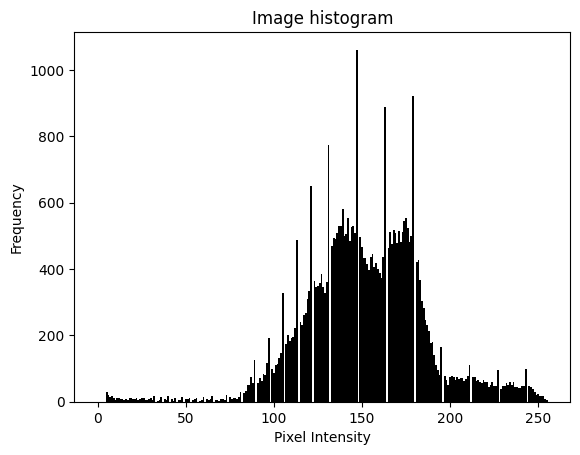

In [7]:
hist = np.histogram(x_train[0], bins=256)[0]
hist[:5] = 0
plt.bar(range(256), hist, width=1.0, color='black')
plt.title('Image histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [7]:
def train_classifier(classifier, param_grid, x_train, cv = 5):
    grid_search = GridSearchCV(classifier, param_grid, cv=cv, verbose=0)
    grid_search.fit(x_train, y_train)
    best_model = grid_search.best_estimator_
    return best_model, grid_search.best_params_

def evaluate(classifiers, x_train, x_val):
  for classifier, param_grid in classifiers:
    best_model, best_params = train_classifier(classifier, param_grid, x_train)
    y_pred = best_model.predict(x_val)

    print(f'{classifier.__class__.__name__}')
    print('Best Parameters:', best_params)
    report = classification_report(y_val, y_pred, output_dict=True, digits=4)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1_score = report['weighted avg']['f1-score']
    accuracy = report['accuracy']
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1_score}')
    print(f'Accuracy: {accuracy}')
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, xticklabels=class_names, yticklabels=class_names, fmt='d')
    plt.show()

In [8]:
def objective(trial, X_train, y_train):
    classifier_name = trial.suggest_categorical('classifier', ['RandomForest', 'KNN', 'AdaBoost', 'XGBoost'])

    if classifier_name == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 10, 200, step=10)
        max_depth = trial.suggest_int('max_depth', 2, 20, step=2)
        if trial.number == 0:
            n_estimators = 100
            max_depth = None
        clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
    
    elif classifier_name == 'KNN':
        n_neighbors = trial.suggest_int('n_neighbors', 1, 20)
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        if trial.number == 0:
            n_neighbors = 5
            weights = 'uniform'
        clf = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
    
    elif classifier_name == 'AdaBoost':
        n_estimators = trial.suggest_int('n_estimators', 10, 200, step=10)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0, log=True)
        if trial.number == 0:
            n_estimators = 50
            learning_rate = 1.0
        clf = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=42, algorithm='SAMME')
    
    elif classifier_name == "XGBoost":
        n_estimators = trial.suggest_int('n_estimators', 10, 200, step=10)
        max_depth = trial.suggest_int('max_depth', 2, 20, step=2)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1.0, log=True)
        if trial.number == 0:
            n_estimators = 100
            max_depth = 6
            learning_rate = 0.3
        clf = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=42, n_jobs=-1)
    
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1).mean()
    return score

In [9]:
def optuna_fun(X_train, y_train):
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials=50)
    
    print("Best trial:")
    trial = study.best_trial
    
    print(f"    Accuracy: {trial.value}")
    print("Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
    optuna.visualization.plot_optimization_history(study).show(renderer="browser")
    optuna.visualization.plot_slice(study).show(renderer="browser")

In [10]:
rf_param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'n_jobs': [-1]}
knn_param_grid = {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance'], 'n_jobs': [-1]}
adaboost_param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1.0], 'algorithm': ["SAMME"]}
xgboost_param_grid = {'n_estimators': [50, 100, 150],
                      'max_depth': [3, 4, 5],
                      'n_jobs': [-1]}
classifiers = [
    (RandomForestClassifier(), rf_param_grid),
    (KNeighborsClassifier(), knn_param_grid),
    (AdaBoostClassifier(), adaboost_param_grid),
    (XGBClassifier(), xgboost_param_grid)
]

# Original

In [15]:
X_train = to_histogram(x_train, original=True)
X_test = to_histogram(x_test, original=True)
X_val = to_histogram(x_val, original=True)

RandomForestClassifier
Best Parameters: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.7792165049274054
Recall: 0.7748815165876777
F1 Score: 0.7748998220339245
Accuracy: 0.7748815165876777


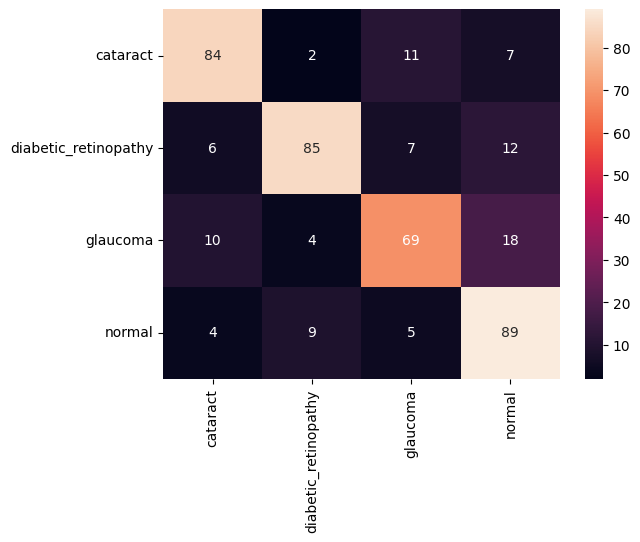

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 3, 'weights': 'distance'}
Precision: 0.6480174154263056
Recall: 0.6587677725118484
F1 Score: 0.6445392336319428
Accuracy: 0.6587677725118484


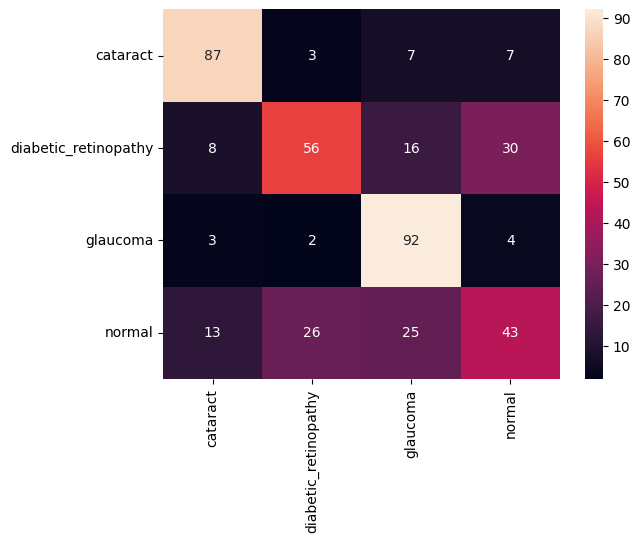

AdaBoostClassifier
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
Precision: 0.6796977938521926
Recall: 0.6635071090047393
F1 Score: 0.6574069053814088
Accuracy: 0.6635071090047393


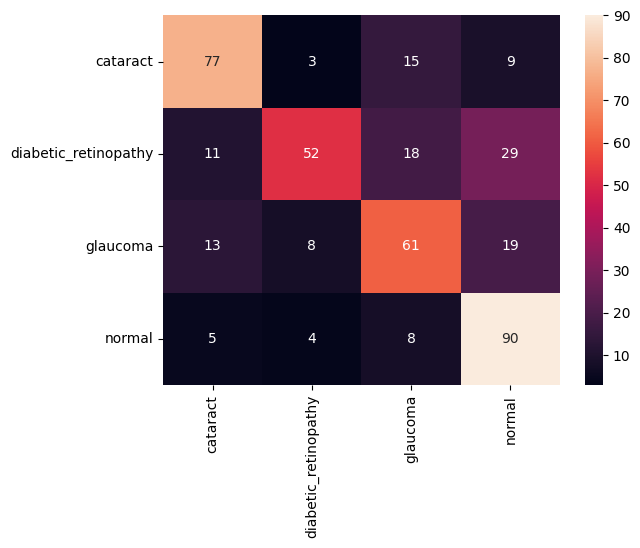

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.7679173502248147
Recall: 0.7582938388625592
F1 Score: 0.7602070122136042
Accuracy: 0.7582938388625592


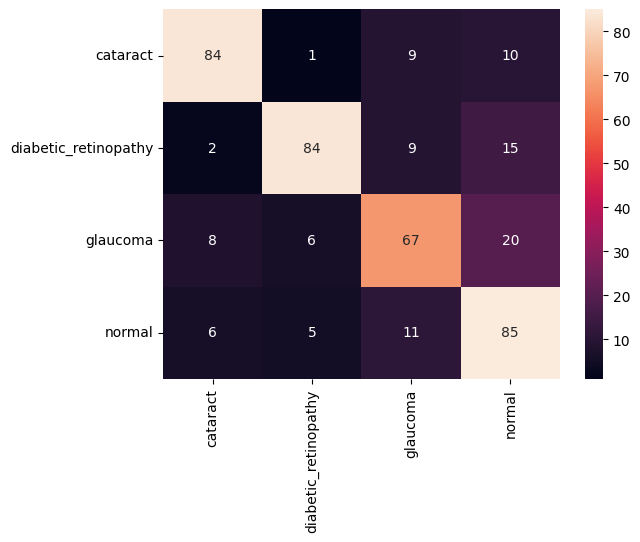

In [13]:
evaluate(classifiers, x_train_hist, x_val_hist)

In [38]:
optuna_fun(X_train, y_train)

[I 2024-08-15 19:48:42,975] A new study created in memory with name: no-name-2a92d32c-b95f-44af-ba1e-9e4946bf10b8
[I 2024-08-15 19:48:44,312] Trial 0 finished with value: 0.5253443235520387 and parameters: {'classifier': 'KNN', 'n_neighbors': 2, 'weights': 'uniform'}. Best is trial 0 with value: 0.5253443235520387.
[I 2024-08-15 19:48:50,619] Trial 1 finished with value: 0.5790091218815255 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 170, 'learning_rate': 0.21615322293224834}. Best is trial 1 with value: 0.5790091218815255.
[I 2024-08-15 19:48:51,354] Trial 2 finished with value: 0.5143752060666007 and parameters: {'classifier': 'KNN', 'n_neighbors': 7, 'weights': 'uniform'}. Best is trial 1 with value: 0.5790091218815255.
[I 2024-08-15 19:48:51,923] Trial 3 finished with value: 0.5211944169688977 and parameters: {'classifier': 'KNN', 'n_neighbors': 8, 'weights': 'distance'}. Best is trial 1 with value: 0.5790091218815255.
[I 2024-08-15 19:48:58,171] Trial 4 finished with

Best trial:
    Accuracy: 0.731985492911309
Params: 
    classifier: XGBoost
    n_estimators: 130
    max_depth: 12
    learning_rate: 0.1824929925758725


# LBP

In [16]:
del X_train, X_test, X_val
x_train_lbp = to_lbp(x_train)
x_test_lbp = to_lbp(x_test)
x_val_lbp = to_lbp(x_val)

x_train_hist = to_histogram(x_train_lbp)
x_test_hist = to_histogram(x_test_lbp)
x_val_hist = to_histogram(x_val_lbp)

RandomForestClassifier
Best Parameters: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.7356127173745858
Recall: 0.7274881516587678
F1 Score: 0.7298668664639348
Accuracy: 0.7274881516587678


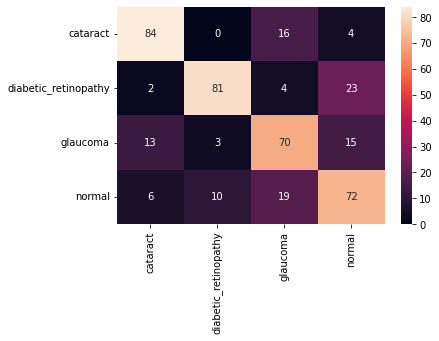

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 7, 'weights': 'distance'}
Precision: 0.6895824009676533
Recall: 0.6848341232227488
F1 Score: 0.6854135152840531
Accuracy: 0.6848341232227488


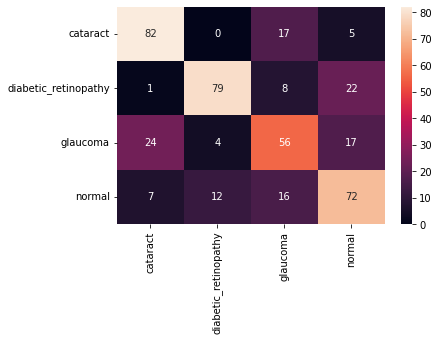

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.7035432544022591
Recall: 0.6469194312796208
F1 Score: 0.6543756896561671
Accuracy: 0.6469194312796208


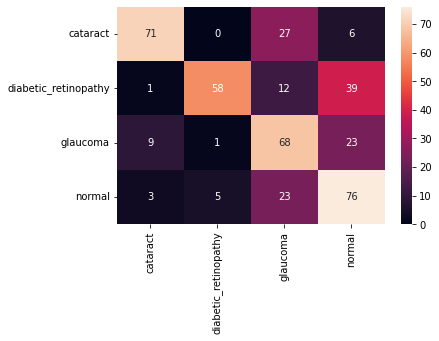

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.7358872393784758
Recall: 0.7274881516587678
F1 Score: 0.7303108210721005
Accuracy: 0.7274881516587678


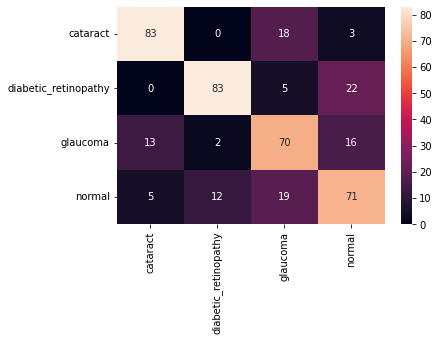

In [12]:
evaluate(classifiers, x_train_hist, x_val_hist)

In [41]:
optuna_fun(x_train_hist, y_train)

[I 2024-08-15 19:57:17,918] A new study created in memory with name: no-name-cd94f59a-df16-440d-993d-2a33a80a83b0
[I 2024-08-15 19:57:18,646] Trial 0 finished with value: 0.6368282228816354 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 140, 'learning_rate': 0.03277929370049765}. Best is trial 0 with value: 0.6368282228816354.
[I 2024-08-15 19:57:20,388] Trial 1 finished with value: 0.7293205846796351 and parameters: {'classifier': 'XGBoost', 'n_estimators': 110, 'max_depth': 12, 'learning_rate': 0.18129866858996216}. Best is trial 1 with value: 0.7293205846796351.
[I 2024-08-15 19:57:20,668] Trial 2 finished with value: 0.6901800197823936 and parameters: {'classifier': 'RandomForest', 'n_estimators': 10, 'max_depth': 18}. Best is trial 1 with value: 0.7293205846796351.
[I 2024-08-15 19:57:20,978] Trial 3 finished with value: 0.6756636993076163 and parameters: {'classifier': 'KNN', 'n_neighbors': 14, 'weights': 'uniform'}. Best is trial 1 with value: 0.7293205846796351.
[I 

Best trial:
    Accuracy: 0.7296173205846795
Params: 
    classifier: XGBoost
    n_estimators: 110
    max_depth: 18
    learning_rate: 0.14844937653540352


# PCA

In [17]:
del x_train_lbp, x_test_lbp, x_val_lbp
del x_train_hist, x_test_hist, x_val_hist
x_train_pca, _ = to_pca(x_train, 30)
x_test_pca, _ = to_pca(x_test, 30)
x_val_pca, _ = to_pca(x_val, 30)

RandomForestClassifier
Best Parameters: {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.5619207414052326
Recall: 0.5355450236966824
F1 Score: 0.5405767142491466
Accuracy: 0.5355450236966824


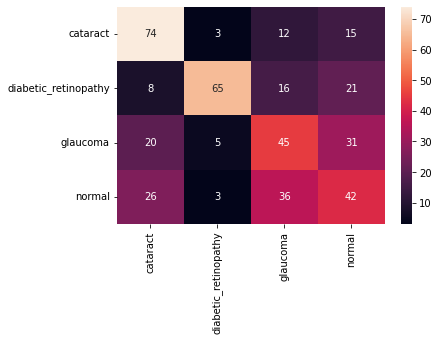

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 5, 'weights': 'distance'}
Precision: 0.5159216420129316
Recall: 0.504739336492891
F1 Score: 0.5081010696058456
Accuracy: 0.504739336492891


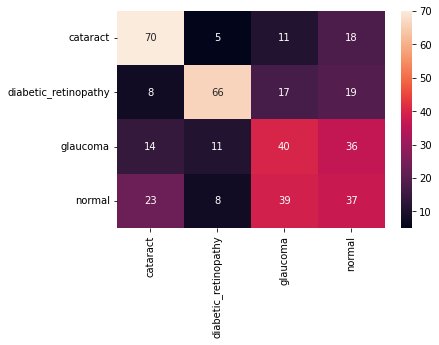

AdaBoostClassifier
Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Precision: 0.5218018381409976
Recall: 0.5071090047393365
F1 Score: 0.5104753220847558
Accuracy: 0.5071090047393365


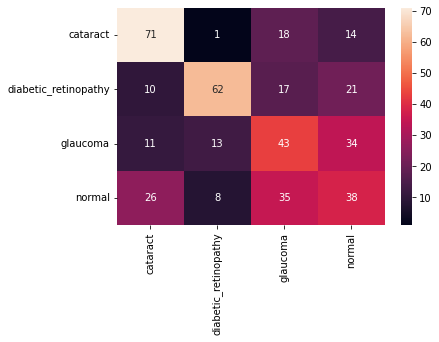

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.5481770974028674
Recall: 0.533175355450237
F1 Score: 0.5361647560619579
Accuracy: 0.533175355450237


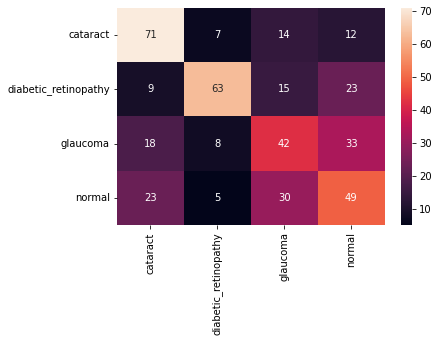

In [30]:
evaluate(classifiers, x_train_pca, x_val_pca)

In [43]:
optuna_fun(x_train_pca, y_train)

[I 2024-08-15 20:05:29,308] A new study created in memory with name: no-name-60e9b327-fbf4-4296-9c58-516374ca75bd
[I 2024-08-15 20:05:30,720] Trial 0 finished with value: 0.7272460709968128 and parameters: {'classifier': 'RandomForest', 'n_estimators': 20, 'max_depth': 4}. Best is trial 0 with value: 0.7272460709968128.
[I 2024-08-15 20:05:32,925] Trial 1 finished with value: 0.5725011539729641 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 190, 'learning_rate': 0.23225339597676956}. Best is trial 0 with value: 0.7272460709968128.
[I 2024-08-15 20:05:33,517] Trial 2 finished with value: 0.561225629190021 and parameters: {'classifier': 'RandomForest', 'n_estimators': 60, 'max_depth': 2}. Best is trial 0 with value: 0.7272460709968128.
[I 2024-08-15 20:05:41,568] Trial 3 finished with value: 0.734659193317947 and parameters: {'classifier': 'XGBoost', 'n_estimators': 160, 'max_depth': 16, 'learning_rate': 0.06098197344598659}. Best is trial 3 with value: 0.734659193317947.
[I 

Best trial:
    Accuracy: 0.7521578195406089
Params: 
    classifier: XGBoost
    n_estimators: 180
    max_depth: 6
    learning_rate: 0.40400978457412096


# Sobel

In [18]:
del x_train_pca, x_test_pca, x_val_pca
x_train_sobel = to_sobel(x_train)
x_test_sobel = to_sobel(x_test)
x_val_sobel = to_sobel(x_val)

x_train_hist = to_histogram(x_train_sobel)
x_test_hist = to_histogram(x_test_sobel)
x_val_hist = to_histogram(x_val_sobel)

RandomForestClassifier
Best Parameters: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.6590724441435342
Recall: 0.6658767772511849
F1 Score: 0.6507289193629748
Accuracy: 0.6658767772511849


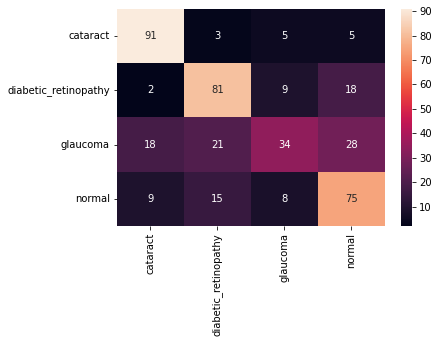

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 5, 'weights': 'distance'}
Precision: 0.4700847534194894
Recall: 0.4597156398104265
F1 Score: 0.4622965800610996
Accuracy: 0.4597156398104265


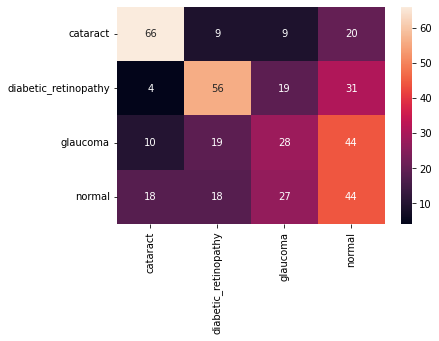

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.6114638087611495
Recall: 0.6161137440758294
F1 Score: 0.6127560202151087
Accuracy: 0.6161137440758294


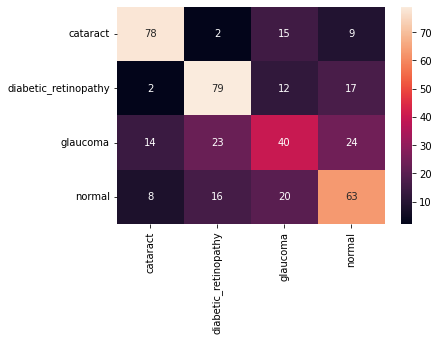

XGBClassifier
Best Parameters: {'max_depth': 3, 'n_estimators': 100, 'n_jobs': -1}
Precision: 0.6461201508919677
Recall: 0.6516587677725119
F1 Score: 0.6464568611835885
Accuracy: 0.6516587677725119


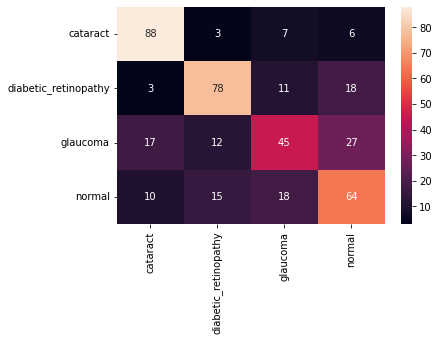

In [35]:
evaluate(classifiers, x_train_hist, x_val_hist)

In [45]:
optuna_fun(x_train_hist, y_train)

[I 2024-08-15 20:07:12,418] A new study created in memory with name: no-name-0967400b-bdd8-480c-ae0a-52f022fccea6
[I 2024-08-15 20:07:12,753] Trial 0 finished with value: 0.41565622595889656 and parameters: {'classifier': 'KNN', 'n_neighbors': 10, 'weights': 'uniform'}. Best is trial 0 with value: 0.41565622595889656.
[I 2024-08-15 20:07:15,328] Trial 1 finished with value: 0.3590262666227058 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 90, 'learning_rate': 0.012037426685505942}. Best is trial 0 with value: 0.41565622595889656.
[I 2024-08-15 20:07:15,599] Trial 2 finished with value: 0.43937135949005385 and parameters: {'classifier': 'RandomForest', 'n_estimators': 10, 'max_depth': 2}. Best is trial 2 with value: 0.43937135949005385.
[I 2024-08-15 20:07:19,738] Trial 3 finished with value: 0.4506372128805364 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 150, 'learning_rate': 0.10093606893012227}. Best is trial 3 with value: 0.4506372128805364.
[I 2024-08-15 2

Best trial:
    Accuracy: 0.6086585339048247
Params: 
    classifier: XGBoost
    n_estimators: 100
    max_depth: 8
    learning_rate: 0.1653210741395309


# Clahe

In [19]:
del x_train_sobel, x_test_sobel, x_val_sobel
del x_train_hist, x_test_hist, x_val_hist
x_train_clahe = to_clahe(x_train)
x_test_clahe = to_clahe(x_test)
x_val_clahe = to_clahe(x_val)

x_train_hist = to_histogram(x_train_clahe)
x_test_hist = to_histogram(x_test_clahe)
x_val_hist = to_histogram(x_val_clahe)

RandomForestClassifier
Best Parameters: {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.7820420617337493
Recall: 0.7772511848341233
F1 Score: 0.7779613780270495
Accuracy: 0.7772511848341233


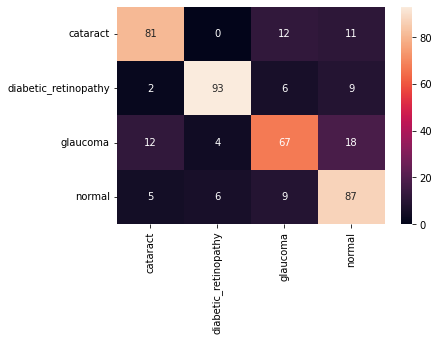

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 5, 'weights': 'distance'}
Precision: 0.710214170893268
Recall: 0.7037914691943128
F1 Score: 0.7057390021570901
Accuracy: 0.7037914691943128


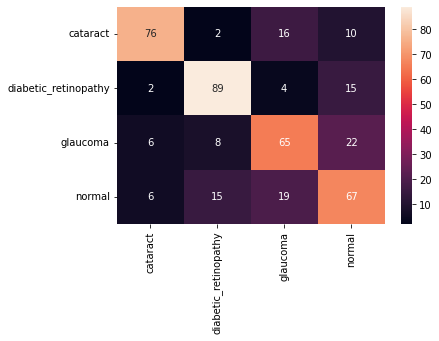

AdaBoostClassifier
Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Precision: 0.7652592338516618
Recall: 0.7606635071090048
F1 Score: 0.7594301307900138
Accuracy: 0.7606635071090048


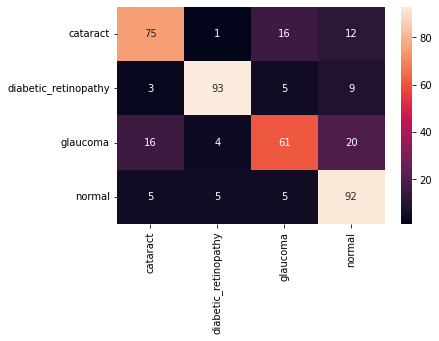

XGBClassifier
Best Parameters: {'max_depth': 4, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.8005256954707345
Recall: 0.7962085308056872
F1 Score: 0.7964517804855585
Accuracy: 0.7962085308056872


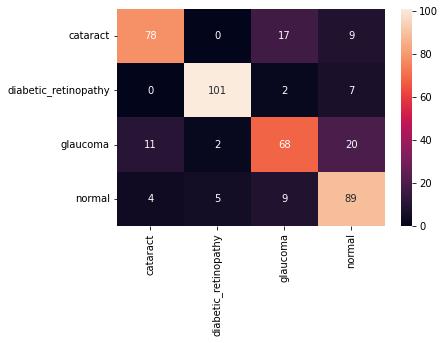

In [37]:
evaluate(classifiers, x_train_hist, x_val_hist)

In [47]:
optuna_fun(x_train_hist, y_train)

[I 2024-08-15 20:12:07,745] A new study created in memory with name: no-name-53896010-219a-4881-878a-d1d4aee8f6f1
[I 2024-08-15 20:12:09,857] Trial 0 finished with value: 0.6798074513682824 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 160, 'learning_rate': 0.02833210427043233}. Best is trial 0 with value: 0.6798074513682824.
[I 2024-08-15 20:12:17,348] Trial 1 finished with value: 0.6602470601164964 and parameters: {'classifier': 'AdaBoost', 'n_estimators': 200, 'learning_rate': 0.11317039447480688}. Best is trial 0 with value: 0.6798074513682824.
[I 2024-08-15 20:12:25,294] Trial 2 finished with value: 0.7820947356852401 and parameters: {'classifier': 'XGBoost', 'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.5256765621257029}. Best is trial 2 with value: 0.7820947356852401.
[I 2024-08-15 20:12:25,590] Trial 3 finished with value: 0.6889904385097264 and parameters: {'classifier': 'KNN', 'n_neighbors': 1, 'weights': 'uniform'}. Best is trial 2 with value: 0.78209

Best trial:
    Accuracy: 0.7906908451478184
Params: 
    classifier: XGBoost
    n_estimators: 200
    max_depth: 6
    learning_rate: 0.12605082748416016


# Clahe into PCA

In [30]:
del x_train_hist, x_test_hist, x_val_hist
x_train_clahe = to_clahe(x_train)
x_test_clahe = to_clahe(x_test)
x_val_clahe = to_clahe(x_val)

x_train_pca, _ = to_pca(x_train_clahe, 30)
x_test_pca, _ = to_pca(x_test_clahe, 30)
x_val_pca, _ = to_pca(x_val_clahe, 30)

RandomForestClassifier
Best Parameters: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1}
Precision: 0.5424903478122269
Recall: 0.523696682464455
F1 Score: 0.5306060895170833
Accuracy: 0.523696682464455


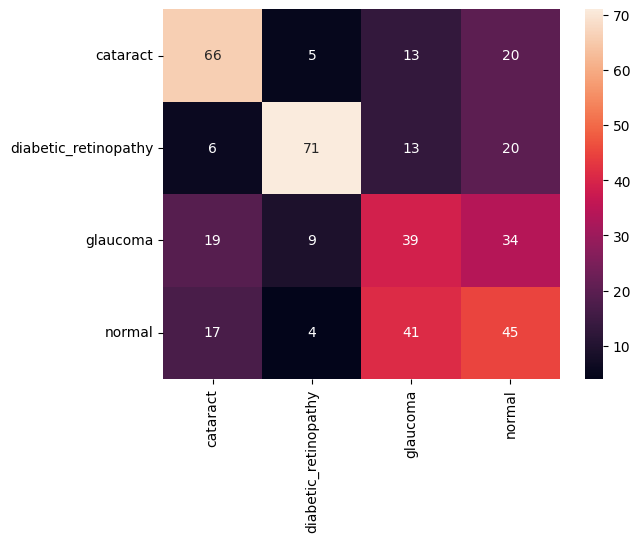

KNeighborsClassifier
Best Parameters: {'n_jobs': -1, 'n_neighbors': 3, 'weights': 'distance'}
Precision: 0.5140511373759314
Recall: 0.514218009478673
F1 Score: 0.5125654196617215
Accuracy: 0.514218009478673


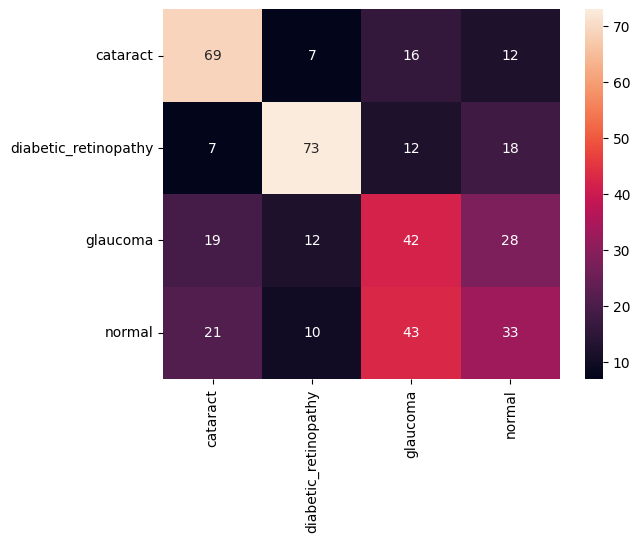

AdaBoostClassifier
Best Parameters: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
Precision: 0.5294683373464609
Recall: 0.5
F1 Score: 0.5104116725812691
Accuracy: 0.5


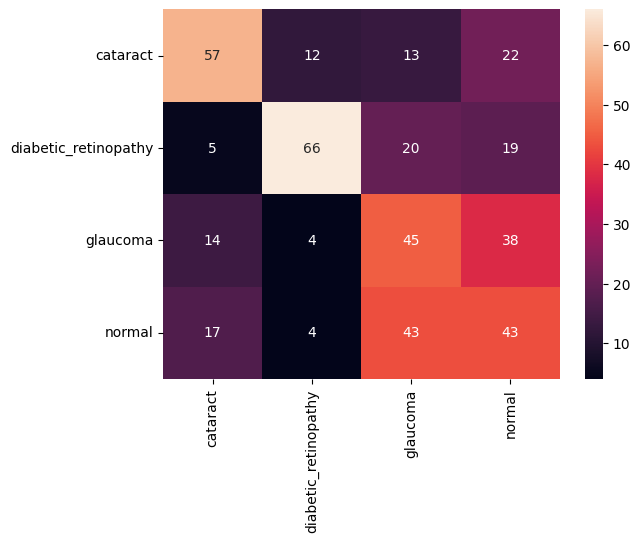

XGBClassifier
Best Parameters: {'max_depth': 5, 'n_estimators': 150, 'n_jobs': -1}
Precision: 0.5219560675979047
Recall: 0.5071090047393365
F1 Score: 0.5127297811256023
Accuracy: 0.5071090047393365


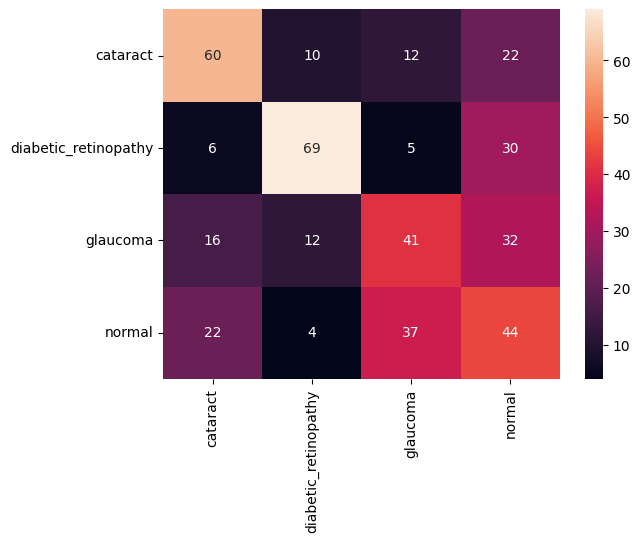

In [31]:
evaluate(classifiers, x_train_pca, x_val_pca)

In [32]:
optuna_fun(x_train_pca, y_train)

[I 2024-08-16 14:45:01,835] A new study created in memory with name: no-name-b8d889e0-85ec-43bf-8e58-4ee028015548
[I 2024-08-16 14:45:04,355] Trial 0 finished with value: 0.7041244092757445 and parameters: {'classifier': 'XGBoost', 'n_estimators': 180, 'max_depth': 12, 'learning_rate': 0.12394436103884814}. Best is trial 0 with value: 0.7041244092757445.
[I 2024-08-16 14:45:05,280] Trial 1 finished with value: 0.6273300362677217 and parameters: {'classifier': 'RandomForest', 'n_estimators': 100, 'max_depth': 6}. Best is trial 0 with value: 0.7041244092757445.
[I 2024-08-16 14:45:06,079] Trial 2 finished with value: 0.5226864490603363 and parameters: {'classifier': 'RandomForest', 'n_estimators': 70, 'max_depth': 2}. Best is trial 0 with value: 0.7041244092757445.
[I 2024-08-16 14:45:13,696] Trial 3 finished with value: 0.6987879986811738 and parameters: {'classifier': 'XGBoost', 'n_estimators': 140, 'max_depth': 20, 'learning_rate': 0.07441301455107956}. Best is trial 0 with value: 0.7

Best trial:
    Accuracy: 0.7165741290251676
Params: 
    classifier: XGBoost
    n_estimators: 120
    max_depth: 6
    learning_rate: 0.326755737637354
